# Day 6 - 10: Customer Intelligence

1. Business Problem
Who are our customers and where should we focus retention?

2. Dataset
What does each row represent?
What are the limitations?

3. Data Quality
Missing values
Duplicates
Cancellations
Negative quantities
Outliers

4. Exploratory Analysis
Revenue over time
Customers
Countries
Orders
Products

5. Customer-Level Feature Engineering
RFM
AOV
Purchase frequency
Product diversity
Cancellation behavior

6. Customer Segmentation
RFM analysis
K-Means
Cluster interpretation

7. Churn Definition
What does "inactive" mean?
Why did I choose this threshold?

8. Churn Prediction
Baseline
Model
Cross-validation
Metrics

9. Business Analysis
Who should we target?
How many customers?
Expected impact?

10. Recommendation
What should the company do?

11. Limitations
What can't this analysis tell us?

12. Next Step
What experiment/data would I want next?

In [1]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
online_retail = fetch_ucirepo(id=352) 
  
# data (as pandas dataframes) 
x = online_retail.data.features 
y = online_retail.data.targets 
data = online_retail.data.original
# metadata 
print(online_retail.metadata) 
  
# variable information 
print(online_retail.variables) 

{'uci_id': 352, 'name': 'Online Retail', 'repository_url': 'https://archive.ics.uci.edu/dataset/352/online+retail', 'data_url': 'https://archive.ics.uci.edu/static/public/352/data.csv', 'abstract': 'This is a transactional data set which contains all the transactions occurring between 01/12/2010 and 09/12/2011 for a UK-based and registered non-store online retail.', 'area': 'Business', 'tasks': ['Classification', 'Clustering'], 'characteristics': ['Multivariate', 'Sequential', 'Time-Series'], 'num_instances': 541909, 'num_features': 6, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': None, 'index_col': ['InvoiceNo', 'StockCode'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2015, 'last_updated': 'Mon Oct 21 2024', 'dataset_doi': '10.24432/C5BW33', 'creators': ['Daqing Chen'], 'intro_paper': {'ID': 361, 'type': 'NATIVE', 'title': 'Data mining for the online retail industry: A case study of RFM model-based customer segmenta

# 1. Explore the data

### Task
Customer
|

├── Recency

├── Frequency

├── Monetary value

├── Average order value

├── Number of products

├── Cancellation rate

└── Country


RFM Segmentation

Champions
Loyal customers
Potential loyalists
At risk
Lost customers
New customers



### Business question

"Who are our customers, which customers are most valuable, and where should we focus retention efforts?"


In [2]:
import pandas as pd
print("Missing values in features:\n", x.isnull().sum())
print("stats:\n", x.describe())
#print(online_retail.data)
df = data.copy()


print("Number of unique customers:", df['CustomerID'].nunique())
print("Number of unique products:", df['StockCode'].nunique())
print("Number of unique countries:", df['Country'].nunique())
print("Number of unique invoices:", df['InvoiceNo'].nunique())
print("Duplicate rows:", df.duplicated().sum())

Missing values in features:
 Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
stats:
             Quantity      UnitPrice     CustomerID
count  541909.000000  541909.000000  406829.000000
mean        9.552250       4.611114   15287.690570
std       218.081158      96.759853    1713.600303
min    -80995.000000  -11062.060000   12346.000000
25%         1.000000       1.250000   13953.000000
50%         3.000000       2.080000   15152.000000
75%        10.000000       4.130000   16791.000000
max     80995.000000   38970.000000   18287.000000
Number of unique customers: 4372
Number of unique products: 4070
Number of unique countries: 38
Number of unique invoices: 25900
Duplicate rows: 5268


# Datasets

- Full dataframe:
    - Add cancellations
    - Convert InvoiceDate 
    - Define revenue

- Purchases:
    - Only succefull purchases

- Orders
    - Grouped by Invoice and Customer

- Cancellations:
    - Cancelled/returned orders

In [23]:
df['IsCancellation'] = df['InvoiceNo'].astype(str).str.upper().str.startswith('C')
df['InvoiceDate'] = pd.to_datetime(df["InvoiceDate"])
df['Revenue'] = df['Quantity'] * df['UnitPrice']

df = df.dropna(subset=['CustomerID'])
df = df.drop_duplicates().copy()

def process_data(df):
    
    invoices_status = df[['CustomerID', 'InvoiceNo', 'IsCancellation']].drop_duplicates()


    purchases = df[~df['IsCancellation'] & (df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()


    orders = (
        purchases
        .groupby(
            ["CustomerID", "InvoiceNo", "InvoiceDate"],
            as_index=False
        )
        .agg(
            OrderValue=("Revenue", "sum"),
            Items=("Quantity", "sum"),
            UniqueProducts=("StockCode", "nunique")
        )
    )

    cancelled_orders = invoices_status.groupby('CustomerID').agg(
        TotalInvoices=('InvoiceNo', 'nunique'),
        CancelledOrders=('IsCancellation', 'sum')
        ).copy()

    cancelled_orders["CancellationRate"] = (
        cancelled_orders["CancelledOrders"]
        / cancelled_orders["TotalInvoices"]
    )
    return orders, cancelled_orders, purchases

# Check cleaned data

In [24]:
orders, cancelled_orders, purchases = process_data(df)

print("Orders:\n", display(orders.head()))

testing_customer = 12346.0

print(f"Orders for customer {testing_customer}:\n", display(orders.loc[testing_customer]))
print(f"Cancelled orders for customer {testing_customer}:\n", display(cancelled_orders.loc[testing_customer]))
print(display(purchases[purchases['CustomerID'] == testing_customer].head()))
print(purchases.head())

,CustomerID,InvoiceNo,InvoiceDate,OrderValue,Items,UniqueProducts
0,12346.0,541431,2011-01-18 10:01:00,77183.60,74215,1
1,12347.0,537626,2010-12-07 14:57:00,711.79,319,31
2,12347.0,542237,2011-01-26 14:30:00,475.39,315,29
3,12347.0,549222,2011-04-07 10:43:00,636.25,483,24
4,12347.0,556201,2011-06-09 13:01:00,382.52,196,18


Orders:
 None


CustomerID                    16232.0
InvoiceNo                      573006
InvoiceDate       2011-10-27 12:16:00
OrderValue                     265.84
Items                             112
UniqueProducts                      6
Name: 12346, dtype: object

Orders for customer 12346.0:
 None


TotalInvoices       2.0
CancelledOrders     1.0
CancellationRate    0.5
Name: 12346.0, dtype: float64

Cancelled orders for customer 12346.0:
 None


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancellation,Revenue
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,False,77183.6


None
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  IsCancellation  \
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom           False   
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom           False   
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom           False   
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom           False   
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom           False   

   Revenue  
0    15.30  
1    20.34  
2    22.00  
3    20.34  
4    20.34  


# Figuring out revenue factors
- Total amount spent by a customer on a product
- Customer data
- Analyze products and sales

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Drop rows with missing CustomerID and Description

print("Purchase rows:", len(purchases))
print("Customers:", purchases["CustomerID"].nunique())
print("Revenue:", purchases["Revenue"].sum())

Purchase rows: 392692
Customers: 4338
Revenue: 8887208.894000001


In [6]:
total_revenue = purchases["Revenue"].sum()
n_orders = purchases["InvoiceNo"].nunique()
n_customers = purchases["CustomerID"].nunique()

avg_order_value = total_revenue / n_orders

print(f"Revenue: £{total_revenue:,.2f}")
print(f"Orders: {n_orders:,}")
print(f"Customers: {n_customers:,}")
print(f"Average order value: £{avg_order_value:,.2f}")

Revenue: £8,887,208.89
Orders: 18,532
Customers: 4,338
Average order value: £479.56


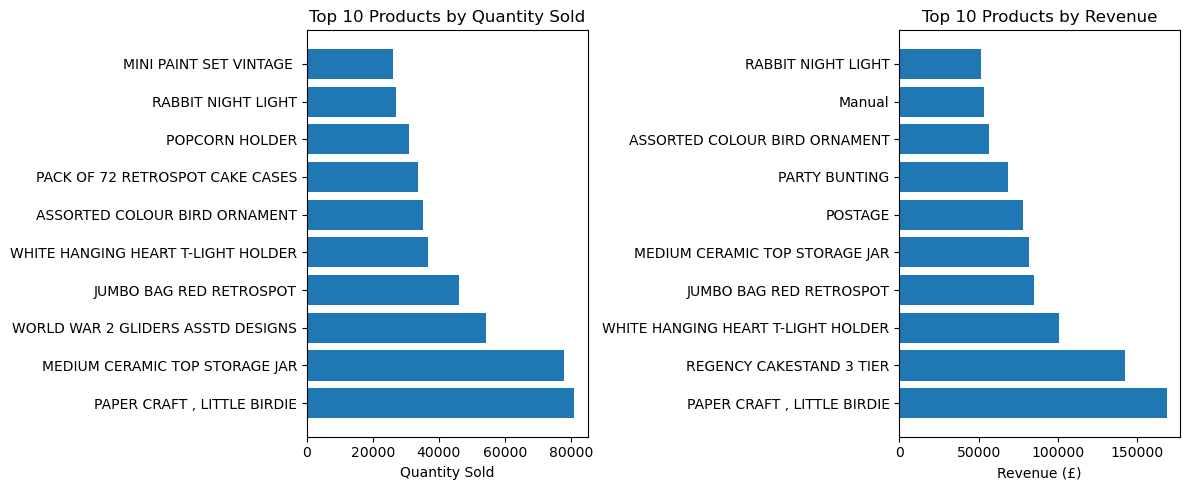

In [7]:
# top 10 products by quantity sold and revenue without cancellations
most_sold_products = purchases.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
highest_revenue_products = purchases.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.barh(most_sold_products.index, most_sold_products.values)
plt.title('Top 10 Products by Quantity Sold')
plt.xlabel('Quantity Sold')
plt.subplot(1, 2, 2)
plt.barh(highest_revenue_products.index, highest_revenue_products.values)
plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue (£)')
plt.tight_layout()
plt.show()

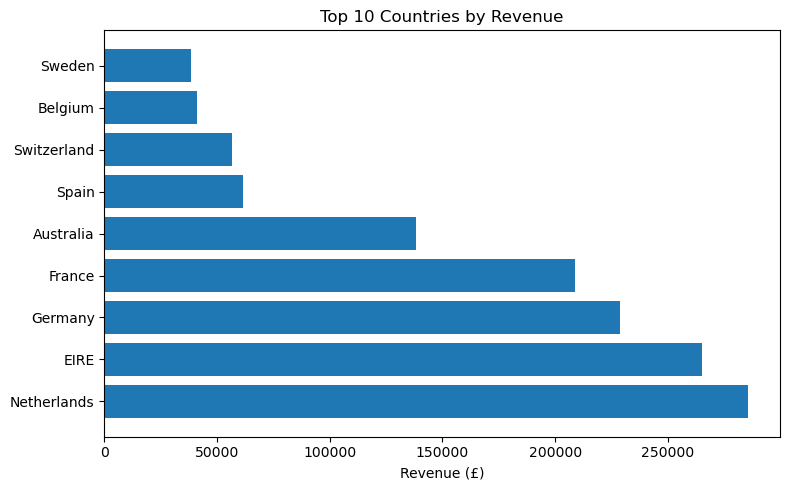

In [8]:
country_revenue = purchases.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)
country_revenue = country_revenue[country_revenue.index != "United Kingdom"]
plt.figure(figsize=(8, 5))
plt.barh(country_revenue.index, country_revenue.values)
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Revenue (£)')
plt.tight_layout()
plt.show()

Time-series data

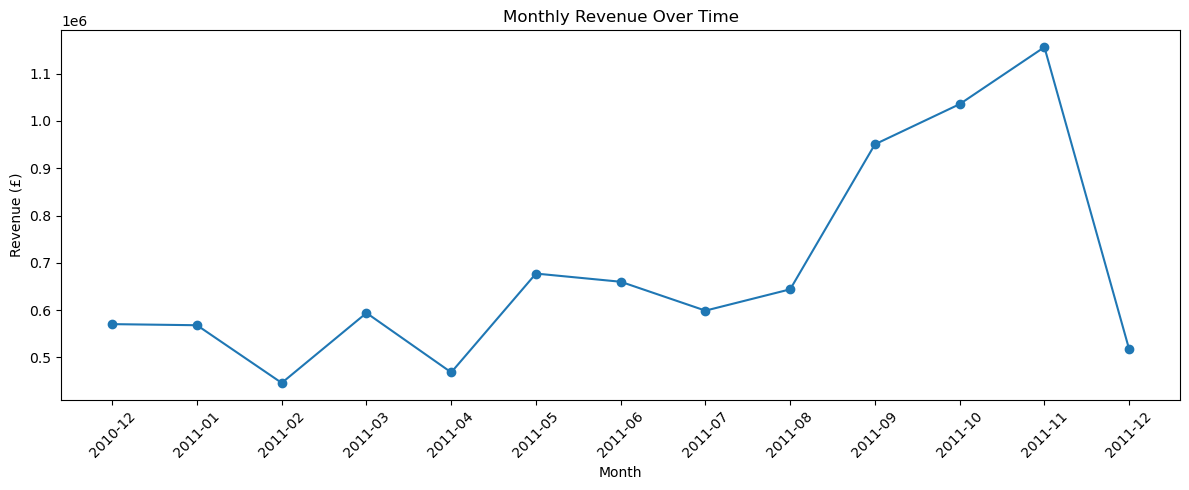

In [9]:
purchases['InvoiceMonth'] = purchases['InvoiceDate'].dt.to_period('M')

monthly_revenue = purchases.groupby('InvoiceMonth')['Revenue'].sum()
plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue.index.astype(str), monthly_revenue.values, marker='o')
plt.title('Monthly Revenue Over Time')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Preprocessing

- Make customer data tables 
- calculate returns, return amount and total amount 

# RFM

In [18]:
import datetime as dt
snapshot_date = purchases['InvoiceDate'].max() + dt.timedelta(days=1)

rfm = (
    purchases.groupby("CustomerID")
    .agg(
        LastPurchase=("InvoiceDate", "max"),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("Revenue", "sum")
    )
)

rfm["Recency"] = (
    snapshot_date - rfm["LastPurchase"]
).dt.days

rfm = rfm.drop(columns="LastPurchase")

display(rfm.head())

,Frequency,Monetary,Recency
CustomerID,,,
12346.0,1,77183.60,326
12347.0,7,4310.00,2
12348.0,4,1797.24,75
12349.0,1,1757.55,19
12350.0,1,334.40,310


# Features

In [26]:

def feature_engineering(orders, cancelled_orders, purchases,rfm):
    order_features = orders.groupby("CustomerID").agg(
        AvgOrderValue=("OrderValue", "mean"),
        AvgItemsPerOrder=("Items", "mean"),
        AvgUniqueItemsPerOrder=("UniqueProducts", "mean"),
    ).copy()
    purchase_features = purchases.groupby("CustomerID").agg(
        TotalRevenue=("Revenue", "sum"),
        TotalItemsPurchased=("Quantity", "sum"),
        TotalUniqueItemsPurchased=("StockCode", "nunique"),
        FirstPurchaseDate=("InvoiceDate", "min"),
        LastPurchaseDate=("InvoiceDate", "max")
    ).copy()
    cancellation_features = cancelled_orders[["CancelledOrders", "CancellationRate"]]
    
    order_dates = (
        orders[
            ["CustomerID", "InvoiceNo", "InvoiceDate"]
        ]
        .sort_values(
            ["CustomerID", "InvoiceDate"]
        )
    )

    order_dates["DaysSincePreviousOrder"] = (
        order_dates
        .groupby("CustomerID")["InvoiceDate"]
        .diff()
        .dt.days
    )
    
    
    interval_features = (
        order_dates
        .groupby("CustomerID")
        .agg(
            MeanDaysBetweenOrders=("DaysSincePreviousOrder", "mean"),
            StdDaysBetweenOrders=("DaysSincePreviousOrder", "std")
        )
    )
    
    
    customers = (
        rfm
        .join(order_features, how="left")
        .join(purchase_features, how="left")
        .join(cancellation_features, how="left")
        .join(interval_features, how="left")
    )


    # Customers with no cancellations
    
    
    customers[
        ["CancelledOrders", "CancellationRate"]
    ] = customers[
        ["CancelledOrders", "CancellationRate"]
    ].fillna(0)

    customers["CustomerTenure"] = customers["LastPurchaseDate"] - customers["FirstPurchaseDate"]

    customer_country = (
        purchases
        .groupby("CustomerID")["Country"]
        .agg(
            lambda x: x.mode().iloc[0]
            if not x.mode().empty
            else np.nan
        )
        .rename("Country")
    )

    customers = customers.join(customer_country)
    return customers

customers = feature_engineering(orders, cancelled_orders, purchases,rfm)

In [27]:

customers["R_Score"] = pd.qcut(
    customers["Recency"].rank(method="first"),
    q=5,
    labels=[5, 4, 3, 2, 1]
).astype(int)
customers["F_Score"] = pd.qcut(
    customers["Frequency"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)
customers["M_Score"] = pd.qcut(
    customers["Monetary"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

customers["RFM_Score"] = (
    customers["R_Score"]
    + customers["F_Score"]
    + customers["M_Score"]
)

customers["RFM_Segment"] = customers["R_Score"].astype(str)+ customers["F_Score"].astype(str)+ customers["M_Score"].astype(str)

# Scoring Metrics

In [28]:
top_customers = customers.sort_values('RFM_Score', ascending=False).head(10)
print(top_customers)

# Segment count (for plotting)
print(customers['RFM_Segment'].value_counts())

            Frequency  Monetary  Recency  AvgOrderValue  AvgItemsPerOrder  \
CustomerID                                                                  
16143.0             6   2424.94        3     404.156667        153.166667   
16954.0             9   2085.08        1     231.675556        117.111111   
12921.0            37  16587.09        9     448.299730        257.459459   
17924.0             7   2962.50       12     423.214286        165.714286   
13784.0            11   2462.79       10     223.890000        226.636364   
13798.0            57  37153.85        1     651.821930        420.140351   
14713.0            11   2662.20        9     242.018182        146.636364   
12901.0            28  17654.54        9     630.519286        824.107143   
14711.0            11   2839.62       10     258.147273         87.818182   
16458.0            18   3482.74        3     193.485556        119.666667   

            AvgUniqueItemsPerOrder  TotalRevenue  TotalItemsPurchased  \
Cu

In [29]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

cluster_features = np.log1p(
    customers[
        ["Recency", "Frequency", "Monetary"]
    ]
)


scaler = StandardScaler()

X_cluster = scaler.fit_transform(cluster_features)
rfm_scaled_df = pd.DataFrame(X_cluster, index=cluster_features.index, columns=cluster_features.columns)

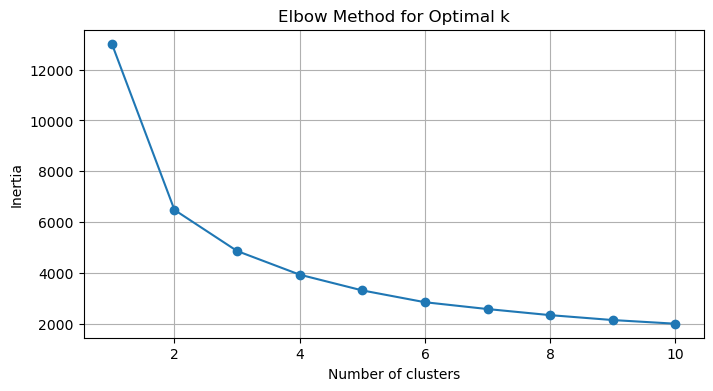

In [30]:
inertia = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(rfm_scaled_df)
    inertia.append(model.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

In [31]:
kmeans = KMeans(n_clusters=4, random_state=42)
customers['Cluster'] = kmeans.fit_predict(rfm_scaled_df)

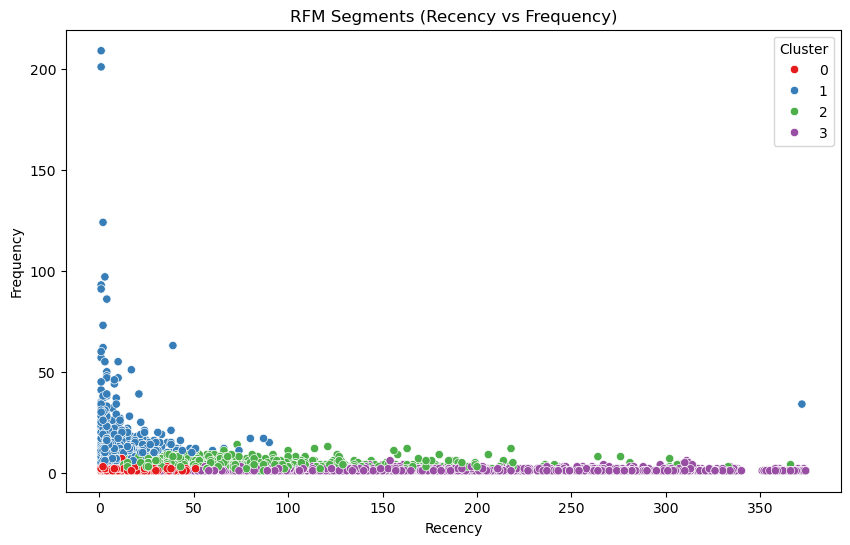

In [32]:
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.scatterplot(data=customers, x='Recency', y='Frequency', hue='Cluster', palette='Set1')
plt.title('RFM Segments (Recency vs Frequency)')
plt.show()

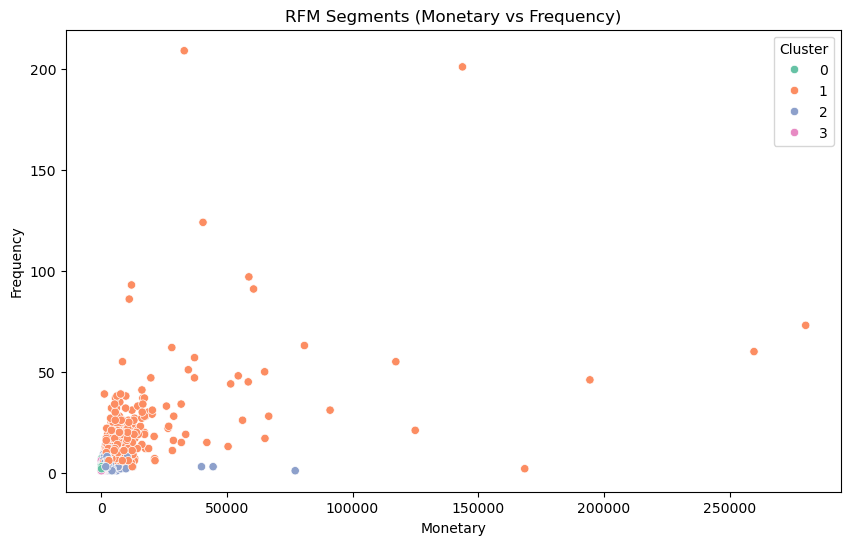

In [33]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=customers, x='Monetary', y='Frequency', hue='Cluster', palette='Set2')
plt.title('RFM Segments (Monetary vs Frequency)')
plt.show()

In [34]:
import plotly.express as px

# Compute cluster summary separately
cluster_summary = customers.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(1)

# Add count of members in each cluster
cluster_summary['Count'] = customers.groupby('Cluster').size()

print(cluster_summary)

# Create the scatter plot
fig = px.scatter_3d(
    customers,
    x='Recency',
    y='Frequency',
    z='Monetary',
    color=customers['Cluster'].astype(str),
    title='3D RFM Cluster Visualization',
    labels={'color': 'Cluster'}
)

fig.show()

         Recency  Frequency  Monetary  Count
Cluster                                     
0           20.0        2.0     510.3    856
1           11.7       13.8    8107.5    707
2           66.7        4.2    1819.3   1185
3          186.7        1.3     353.8   1590


In [35]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(rfm_scaled_df)

labels = kmeans.labels_
score = silhouette_score(rfm_scaled_df, labels)

print(f"Silhouette Score: {score:.3f}")

Silhouette Score: 0.335


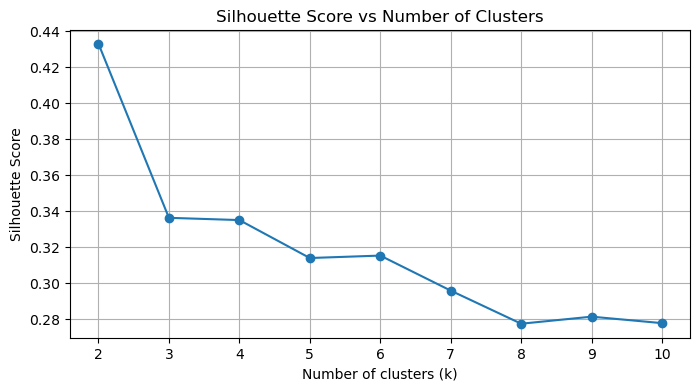

Optimal k (based on silhouette score): 2


In [36]:
sil_scores = []
K = range(2, 11)  # Test k from 2 to 10

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled_df)
    labels = kmeans.labels_
    score = silhouette_score(rfm_scaled_df, labels)
    sil_scores.append(score)

# Plot the scores
plt.figure(figsize=(8,4))
plt.plot(K, sil_scores, marker='o')
plt.title('Silhouette Score vs Number of Clusters')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

# Print best k
best_k = K[sil_scores.index(max(sil_scores))]
print(f"Optimal k (based on silhouette score): {best_k}")

In [37]:
cluster_summary = (
    customers.groupby("Cluster")
    .agg(
        Customers=("Monetary", "size"),
        Recency=("Recency", "mean"),
        Frequency=("Frequency", "mean"),
        Monetary=("Monetary", "mean"),
        AvgOrderValue=("AvgOrderValue", "mean"),
        CancellationRate=("CancellationRate", "mean")
    )
)

display(cluster_summary)

,Customers,Recency,Frequency,Monetary,AvgOrderValue,CancellationRate
Cluster,,,,,,
0,856,20.047897,2.008178,510.281472,280.324181,0.070315
1,707,11.736917,13.775106,8107.548571,621.265972,0.152748
2,1185,66.718987,4.172996,1819.250247,567.011859,0.138326
3,1590,186.730818,1.338994,353.811051,288.478453,0.080215


In [23]:
max_date = purchases["InvoiceDate"].max()

cutoff_date = max_date - pd.Timedelta(days=90)

print("Cutoff:", cutoff_date)
print("Dataset end:", max_date)

Cutoff: 2011-09-10 12:50:00
Dataset end: 2011-12-09 12:50:00


In [24]:
history = purchases[purchases["InvoiceDate"] <= cutoff_date].copy()
future = purchases[purchases["InvoiceDate"] > cutoff_date].copy()

historical_customers = set(history["CustomerID"].unique())
future_customers = set(future["CustomerID"].unique())

customer_target = pd.DataFrame(
    index=list(historical_customers)
)

customer_target.index.name = "CustomerID"

customer_target["Inactive"] = (
    ~customer_target.index.isin(future_customers)
).astype(int)

history_features = (
    history.groupby("CustomerID")
    .agg(
        Recency=("InvoiceDate", lambda x: (cutoff_date - x.max()).days),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("Revenue", "sum"),
        UniqueProducts=("StockCode", "nunique"),
        TotalItems=("Quantity", "sum"),
    )
)

history_orders = (
    history.groupby(
        ["CustomerID", "InvoiceNo"],
        as_index=False
    )
    .agg(
        OrderValue=("Revenue", "sum")
    )
)

order_stats = (
    history_orders.groupby("CustomerID")
    .agg(
        AvgOrderValue=("OrderValue", "mean"),
        MaxOrderValue=("OrderValue", "max")
    )
)

history_features = history_features.join(order_stats)
history_dates = (
    history.groupby("CustomerID")["InvoiceDate"]
    .agg(["min", "max"])
)

history_features["CustomerTenureDays"] = (
    history_dates["max"]
    - history_dates["min"]
).dt.days

In [25]:
model_df = history_features.join(customer_target)

model_df = model_df.dropna()

display(model_df.head())

print(model_df["Inactive"].value_counts())
print(model_df["Inactive"].value_counts(normalize=True))

,Recency,Frequency,Monetary,UniqueProducts,TotalItems,AvgOrderValue,MaxOrderValue,CustomerTenureDays,Inactive
CustomerID,,,,,,,,,
12346.0,235,1,77183.60,1,74215,77183.600000,77183.60,0,1
12347.0,39,5,2790.86,82,1590,558.172000,711.79,237,0
12348.0,158,3,1487.24,22,2124,495.746667,892.80,109,0
12350.0,219,1,334.40,17,197,334.400000,334.40,0,1
12352.0,171,5,1561.81,26,254,312.362000,840.30,34,0


Inactive
0    1921
1    1449
Name: count, dtype: int64
Inactive
0    0.57003
1    0.42997
Name: proportion, dtype: float64


In [26]:
from sklearn.model_selection import train_test_split

X = model_df.drop(columns="Inactive")
y = model_df["Inactive"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

In [27]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report

dummy = DummyClassifier(
    strategy="most_frequent"
)

dummy.fit(X_train, y_train)

dummy_pred = dummy.predict(X_test)

print(classification_report(
    y_test,
    dummy_pred,
    zero_division=0
))

              precision    recall  f1-score   support

           0       0.57      1.00      0.73       481
           1       0.00      0.00      0.00       362

    accuracy                           0.57       843
   macro avg       0.29      0.50      0.36       843
weighted avg       0.33      0.57      0.41       843



In [28]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic = Pipeline([
    (
        "scale",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        )
    )
])

logistic.fit(X_train, y_train)

,steps,"[('scale', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [29]:
log_pred = logistic.predict(X_test)

log_prob = logistic.predict_proba(
    X_test
)[:, 1]

In [30]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

def evaluate_model(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob)
    }

In [31]:
log_results = evaluate_model(
    y_test,
    log_pred,
    log_prob
)

print(log_results)

print(
    confusion_matrix(
        y_test,
        log_pred
    )
)

{'Accuracy': 0.6654804270462633, 'Precision': 0.58298755186722, 'Recall': 0.7762430939226519, 'F1': 0.6658767772511849, 'ROC-AUC': 0.7254338911797475, 'PR-AUC': 0.6221294113157594}
[[280 201]
 [ 81 281]]


In [32]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=400,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_prob = rf.predict_proba(
    X_test
)[:, 1]

rf_results = evaluate_model(
    y_test,
    rf_pred,
    rf_prob
)

print(rf_results)

{'Accuracy': 0.6358244365361803, 'Precision': 0.562929061784897, 'Recall': 0.6795580110497238, 'F1': 0.6157697121401752, 'ROC-AUC': 0.7126267789251215, 'PR-AUC': 0.6206758630268285}


In [33]:
results = pd.DataFrame(
    {
        "Logistic Regression": log_results,
        "Random Forest": rf_results
    }
).T

display(results)

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Logistic Regression,0.665480,0.582988,0.776243,0.665877,0.725434,0.622129
Random Forest,0.635824,0.562929,0.679558,0.615770,0.712627,0.620676
